# Subject-Specific Eye Model Example

This notebook shows how to build and analyze a sequential schematic eye in Optiland from measured geometric data.

The example uses subject-specific biometric inputs such as axial length, corneal thickness, chamber depth, lens thickness, surface curvature, and asphericity. From these values, the notebook constructs the ocular surface stack, visualizes the model, and evaluates the on-axis aberration state.

The workflow covers:
- defining refractive indices for the ocular media
- converting biometric measurements into a sequential surface model
- visualizing the eye in a 2D meridional section
- computing central-field Zernike coefficients
- converting defocus and astigmatism terms into sphere, cylinder, and axis in diopters

The cells are organized in the same order as a typical optics workflow: define inputs, build the model, inspect the geometry, then evaluate its aberrations.

In [1]:
import numpy as np
from optiland import optic
from optiland.materials import IdealMaterial
from optiland.wavefront import ZernikeOPD

In [2]:
# Navarro wide-angle eye refractive indices (Escudero-Sanz and Navarro, 1999) at 543 nm

materials = {
    "cornea": IdealMaterial(1.3777),
    "aqueous_humor": IdealMaterial(1.3391),
    "lens": IdealMaterial(1.4222),
    "vitreous_humor": IdealMaterial(1.3377),
}

# Clinical data of a slightly myopic eye
geometry = {
    "axial_length": 24.305,  # mm
    "cornea_thickness": 0.5615,  # mm
    "anterior_chamber_depth": 3.345,  # mm
    "lens_thickness": 3.17,  # mm
    "cornea_front_curvature": 7.6967,  # mm
    "cornea_front_asphericity": -0.2304,
    "cornea_back_curvature": 6.2343,  # mm
    "cornea_back_asphericity": -0.1444,
    "lens_front_curvature": 10.2,  # mm
    "lens_front_asphericity": -3.1316,
    "lens_back_curvature": -5.4537,  # mm
    "lens_back_asphericity": -4.1655,
    "retina_curvature": -11.3357,  # mm
    "retina_asphericity": -0.0631,
}

## Define Optical Media And Subject Geometry

This section defines the refractive indices used for the ocular media and the measured geometry of the subject eye. The geometric inputs are then used to derive the vitreous depth and construct the sequential model in the next cell.

In [3]:
# Derive the vitreous chamber depth from the measured axial length
vitreous_depth = (
    geometry["axial_length"]
    - geometry["cornea_thickness"]
    - geometry["anterior_chamber_depth"]
    - geometry["lens_thickness"]
)

# Build the subject-specific sequential eye model
eye = optic.Optic()
eye.surfaces.add(index=0, radius=np.inf, thickness=np.inf)

subject_surfaces = [
    (
        "Cornea anterior",
        geometry["cornea_front_curvature"],
        geometry["cornea_thickness"],
        geometry["cornea_front_asphericity"],
        materials["cornea"],
    ),
    (
        "Cornea posterior",
        geometry["cornea_back_curvature"],
        geometry["anterior_chamber_depth"],
        geometry["cornea_back_asphericity"],
        materials["aqueous_humor"],
    ),
    ("Pupil stop", np.inf, 0.0, None, materials["aqueous_humor"]),
    (
        "Lens anterior",
        geometry["lens_front_curvature"],
        geometry["lens_thickness"],
        geometry["lens_front_asphericity"],
        materials["lens"],
    ),
    (
        "Lens posterior",
        geometry["lens_back_curvature"],
        vitreous_depth,
        geometry["lens_back_asphericity"],
        materials["vitreous_humor"],
    ),
    (
        "Retina",
        geometry["retina_curvature"],
        0.0,
        geometry["retina_asphericity"],
        materials["vitreous_humor"],
    ),
]

for i, (label, radius, thickness, conic, material) in enumerate(subject_surfaces, start=1):
    surface_kwargs = {
        "index": i,
        "radius": radius,
        "thickness": thickness,
        "material": material,
        "is_stop": label == "Pupil stop",
    }
    if conic is not None:
        surface_kwargs["conic"] = conic
    eye.surfaces.add(**surface_kwargs)

# Use a fixed 3.0 mm analysis pupil for ray tracing and aberration evaluation
eye.set_aperture(
    aperture_type="float_by_stop_size",
    value=3.0,
)

eye.fields.set_type(field_type="angle")
for angle_deg in [0, 15, 30, 45]:
    eye.fields.add(angle_deg)

eye.wavelengths.add(0.543)

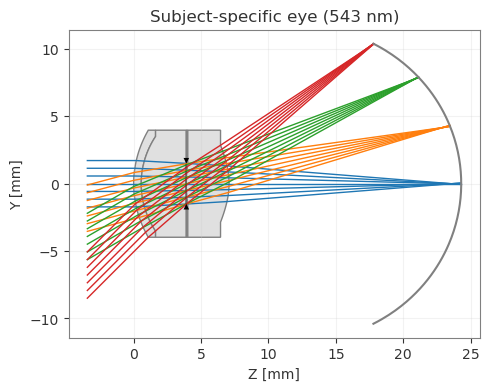

In [4]:
# Plot the subject-specific eye in a 2D YZ meridional view
fig, ax = eye.draw(
    fields="all",
    wavelengths="primary",
    num_rays=7,
    projection="YZ",
    title="Subject-specific eye (543 nm)",
)

## Compute On-Axis Zernike Power

The next cell evaluates the central field using a Noll-indexed Zernike expansion. It then extracts the defocus and astigmatism terms and converts them into clinical dioptric quantities: sphere, cylinder, and axis.

In [5]:
# Build a Noll-indexed Zernike expansion for the central (on-axis) field
zernike_opd = ZernikeOPD(
    eye,
    field=(0.0, 0.0),
    wavelength=0.543,
    num_rings=64,
    num_terms=15,
    zernike_type="noll",
)

# Noll indices used in the clinical power conversion below
NOLL_DEFOCUS_INDEX = 4
NOLL_ASTIGMATISM_OBLIQUE_INDEX = 5
NOLL_ASTIGMATISM_VERTICAL_INDEX = 6

def calculate_spherocylindrical_coefficients(zernike_coefficients):
    """Return the Noll defocus and astigmatism coefficients."""
    defocus_coefficient = zernike_coefficients[NOLL_DEFOCUS_INDEX - 1]
    astigmatism_coefficients = [
        zernike_coefficients[NOLL_ASTIGMATISM_OBLIQUE_INDEX - 1],
        zernike_coefficients[NOLL_ASTIGMATISM_VERTICAL_INDEX - 1],
    ]
    return defocus_coefficient, astigmatism_coefficients

def zernike_to_diopters(
    zernike_coefficients,
    pupil_diameter_mm,
    wavelength_um=0.543,
    coefficient_unit="waves",
):
    """Convert Noll defocus and astigmatism terms to clinical power values."""
    z4 = zernike_coefficients[NOLL_DEFOCUS_INDEX - 1]
    z5 = zernike_coefficients[NOLL_ASTIGMATISM_OBLIQUE_INDEX - 1]
    z6 = zernike_coefficients[NOLL_ASTIGMATISM_VERTICAL_INDEX - 1]

    if coefficient_unit == "waves":
        coefficient_scale_m = wavelength_um * 1e-6
    elif coefficient_unit == "microns":
        coefficient_scale_m = 1e-6
    else:
        raise ValueError("coefficient_unit must be 'waves' or 'microns'.")

    z4_m = z4 * coefficient_scale_m
    z5_m = z5 * coefficient_scale_m
    z6_m = z6 * coefficient_scale_m

    pupil_radius_m = 0.5 * pupil_diameter_mm * 1e-3

    # Power-vector conversion for normalized Noll Zernike polynomials
    M = -(4.0 * np.sqrt(3.0) * z4_m) / (pupil_radius_m**2)
    J45 = -(2.0 * np.sqrt(6.0) * z5_m) / (pupil_radius_m**2)
    J0 = -(2.0 * np.sqrt(6.0) * z6_m) / (pupil_radius_m**2)

    cylinder = -2.0 * np.sqrt(J0**2 + J45**2)
    axis_deg = (0.5 * np.degrees(np.arctan2(J45, J0))) % 180.0
    sphere = M - cylinder / 2.0

    return {
        "M": M,
        "J0": J0,
        "J45": J45,
        "sphere": sphere,
        "cylinder": cylinder,
        "axis_deg": axis_deg,
    }

## Report The Clinical Power Terms

This cell reuses the helper functions from the previous step to extract the defocus and astigmatism coefficients and summarize them as sphere, cylinder, and axis.

In [6]:
# Reuse the helper functions to summarize the central-field refractive state
defocus_coefficient, astigmatism_coefficients = calculate_spherocylindrical_coefficients(
    zernike_opd.coeffs
)

power = zernike_to_diopters(
    zernike_opd.coeffs,
    pupil_diameter_mm=3.0,
    wavelength_um=0.543,
    coefficient_unit="waves",
)

print(f"Defocus coefficient (Z{NOLL_DEFOCUS_INDEX}): {defocus_coefficient}")
print(
    "Astigmatism coefficients "
    f"(Z{NOLL_ASTIGMATISM_OBLIQUE_INDEX}, Z{NOLL_ASTIGMATISM_VERTICAL_INDEX}): "
    f"{astigmatism_coefficients}"
)
print("\nConverted to diopters:")
print(f"Sphere: {power['sphere']:.4f} D")
print(f"Cylinder: {power['cylinder']:.4f} D")
print(f"Axis: {power['axis_deg']:.2f} deg")

Defocus coefficient (Z4): 1.604325583081637
Astigmatism coefficients (Z5, Z6): [np.float64(-2.746806152451339e-15), np.float64(1.2784658785471617e-13)]

Converted to diopters:
Sphere: -2.6824 D
Cylinder: -0.0000 D
Axis: 89.38 deg


## Further Reading

For more elaborate eye modeling and vision-science simulations, consider exploring [visisipy](https://github.com/MREYE-LUMC/visisipy), an open-source Python package for vision simulations of the eye.

Visisipy provides a higher-level interface for defining eye models and running clinically relevant analyses, and it can use Optiland as an open-source backend for model building and simulation.